#IRWA Project Part 1

Authors: Carla Núñez u214970  /  Julia Pérez u214026  /  Jan Prats u213927

GitHub URL: https://github.com/Januto30/SearchEngine-IRWA_2025

TAG: 24/10/2025


##1. SETUP

In [11]:
from google.colab import drive
drive.mount('/content/drive')

docs_path_json = 'data/fashion_products_dataset.json'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
#Standard library imports
import json
import re
import string
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

#NLTK imports
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

#Download NLTK resources
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
with open(docs_path_json, 'r', encoding='utf-8') as f:
    json_data_products = json.load(f)

# Convert JSON list of dicts into DataFrame
df_products = pd.DataFrame(json_data_products)

##2. PREPROCESSING FUNCTION

In [14]:
def build_terms(line):
    stemmer = PorterStemmer()
    stop_words = set(stopwords.words("english"))      #Stop words

    line= line.lower()                                #Transform in lowercase
    line= re.sub(r'[^a-z0-9\s]', ' ', line)           #Remove non‑alphanumeric characters (removing punctuation marks, keep spaces)
    line= re.sub(r'\s+', ' ', line).strip()           #Collapse multiple spaces into a single space
    line= line.split()                                #Tokenize the text to get a list of terms
    line=[x for x in line if x not in stop_words]     #Eliminate the stopwords
    line=[stemmer.stem(word) for word in line]        #Perform stemming (teacher --> teach)

    return line

#Apply preprocessing to title and description
df_products['title_clean'] = df_products['title'].apply(build_terms)
df_products['description_clean'] = df_products['description'].apply(build_terms)

#Combine product_details into a single text field
def combine_product_details(details_list):
    if isinstance(details_list, list):
        return " ".join([str(list(d.values())[0]) for d in details_list])
    return ""

df_products['product_details_text'] = df_products['product_details'].apply(combine_product_details)

##3. PREPROCESSING FOR EXAMPLE

In [15]:
preprocessed_products = []

for prod in json_data_products:
    #Get the text fields (if missing, use empty string)
    title_raw = prod.get('title', '')
    descr_raw = prod.get('description', '')

    #Apply preprocessing pipeline
    title_tokens = build_terms(title_raw)
    descr_tokens = build_terms(descr_raw)

    #Keep all original fields along with the processed tokens
    prod_processed = {
        **prod,  # conservar tots els camps originals
        'title_tokens': title_tokens,
        'description_tokens': descr_tokens
    }
    preprocessed_products.append(prod_processed)

#Show the first product before and after preprocessing
first_raw = json_data_products[0]
first_proc = preprocessed_products[0]

print("=== Original Product ===")
print(f"Title      : {first_raw.get('title', 'N/A')}")
print(f"Description: {first_raw.get('description', 'N/A')}")

print("\n=== After Preprocessing ===")
print(f"Title Tokens      : {first_proc['title_tokens']}")
print(f"Description Tokens: {first_proc['description_tokens']}")

=== Original Product ===
Title      : Solid Women Multicolor Track Pants
Description: Yorker trackpants made from 100% rich combed cotton giving it a rich look.Designed for Comfort,Skin friendly fabric,itch-free waistband & great for all year round use Proudly made in India

=== After Preprocessing ===
Title Tokens      : ['solid', 'women', 'multicolor', 'track', 'pant']
Description Tokens: ['yorker', 'trackpant', 'made', '100', 'rich', 'comb', 'cotton', 'give', 'rich', 'look', 'design', 'comfort', 'skin', 'friendli', 'fabric', 'itch', 'free', 'waistband', 'great', 'year', 'round', 'use', 'proudli', 'made', 'india']


##4.EXPLORATORY DATA ANALYSIS

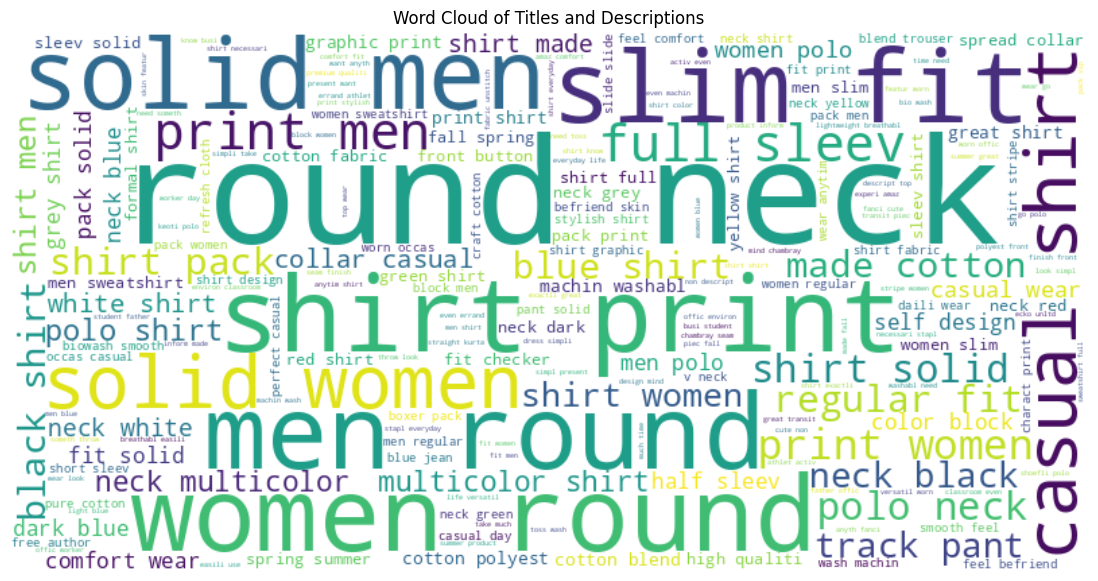

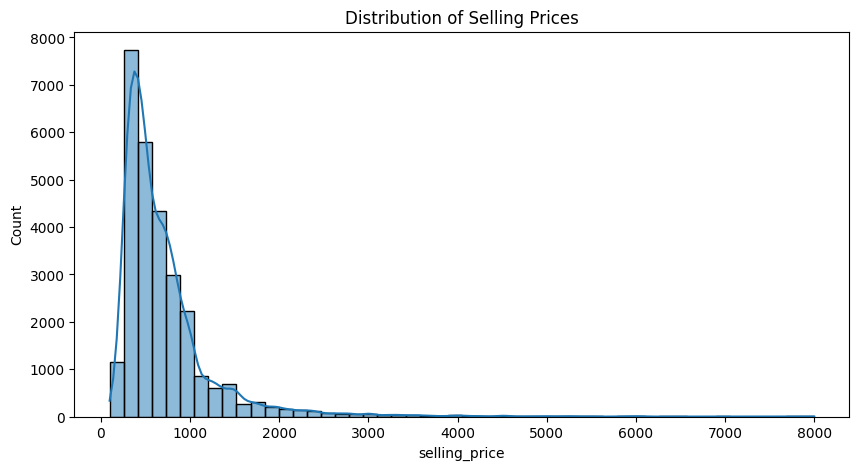

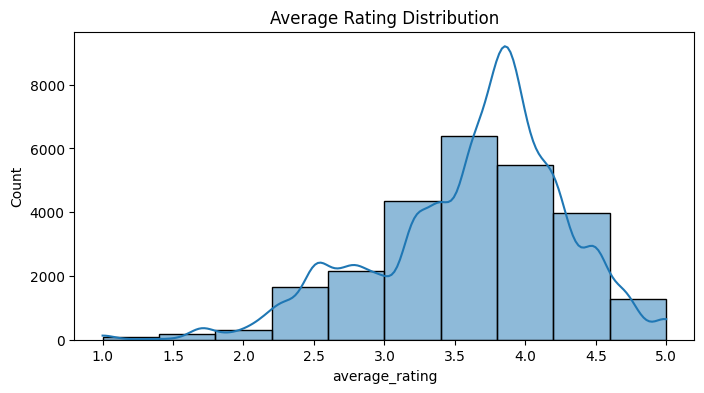

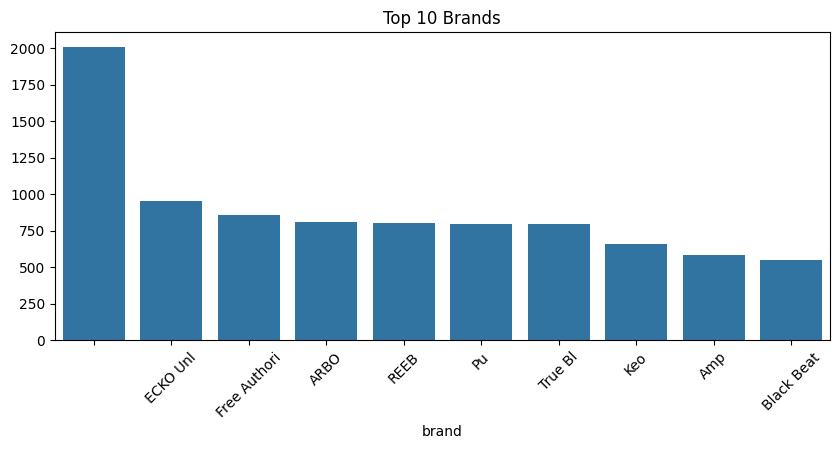

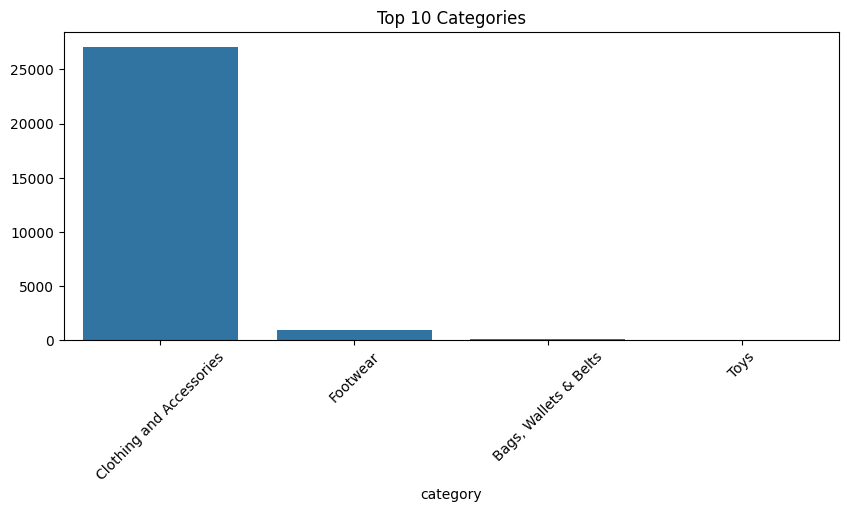

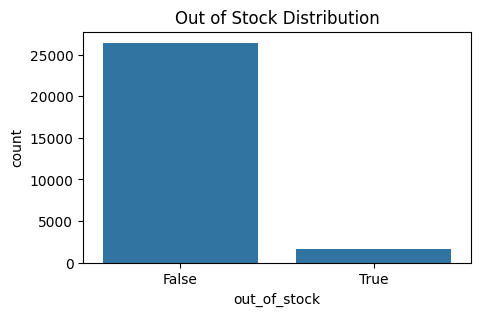

In [16]:
#Word Cloud
text_combined = " ".join([" ".join(x) for x in df_products['title_clean']] +
                         [" ".join(x) for x in df_products['description_clean']])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Titles and Descriptions")
plt.show()

#Distribution of prices
df_products['selling_price'] = pd.to_numeric(df_products['selling_price'].str.replace(',', ''), errors='coerce')
df_products['actual_price'] = pd.to_numeric(df_products['actual_price'].str.replace(',', ''), errors='coerce')

plt.figure(figsize=(10,5))
sns.histplot(df_products['selling_price'].dropna(), bins=50, kde=True)
plt.title("Distribution of Selling Prices")
plt.show()

#Average rating distribution
df_products['average_rating'] = pd.to_numeric(df_products['average_rating'], errors='coerce')

plt.figure(figsize=(8,4))
sns.histplot(df_products['average_rating'].dropna(), bins=10, kde=True)
plt.title("Average Rating Distribution")
plt.show()

#Top brands and categories
top_brands = df_products['brand'].value_counts().head(10)
top_categories = df_products['category'].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_brands.index, y=top_brands.values)
plt.title("Top 10 Brands")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.title("Top 10 Categories")
plt.xticks(rotation=45)
plt.show()

#Out of stock distribution
plt.figure(figsize=(5,3))
sns.countplot(x='out_of_stock', data=df_products)
plt.title("Out of Stock Distribution")
plt.show()

preprocessed_cols = ['pid', 'title_clean', 'description_clean', 'brand', 'category',
                     'sub_category', 'product_details_text', 'seller', 'out_of_stock',
                     'selling_price', 'discount', 'actual_price', 'average_rating', 'url']

df_products[preprocessed_cols].to_csv("preprocessed_fashion_products.csv", index=False)